## AEC Document Collaboration Software: Market Opportunity Analysis
### Strategic Growth Recommendations for Bluebeam
#### Prepared by: Catalina Valencia

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Blues_d")

#### Section 1: Market Sizing (TAM, SAM, SOM)

To assess the growth opportunity for Bluebeam, this analysis estimates the market across three levels:

- **TAM (Total Addressable Market):** The global AEC software market, all potential users of construction technology software worldwide.
- **SAM (Serviceable Addressable Market):** The North American document 
collaboration and management segment, the portion Bluebeam can realistically serve given its current product and geographic presence
- **SOM (Serviceable Obtainable Market):** The architect and engineer user segment within North America, Bluebeam's core customer base and most directly addressable opportunity.

A 5-year forecast horizon (2026–2031) was selected to align with published industry forecast periods and reflect a realistic strategic planning window for market entry decisions.

*Data sources: Fortune Business Insights (2025), Grand View Research (2024), Strategic Revenue Insights (2025), Statista (2024)*

*Note: Base values are sourced from the most recently available industry reports. Global and North America figures are anchored to 2025 reported data; Europe figures are anchored to 2024 reported data. All values from 2026 onward are projected using published CAGR estimates and should be interpreted as estimates.*

In [8]:
# Forecast period: 2026-2031 (5-year horizon from current year)
# Rationale: 2026 is the analysis base year. Most recent reported values 
# used to anchor CAGR projections forward.
years = list(range(2026, 2032))

# Global AEC Software Market ($B)
# 2025 reported value: $10.76B — Source: Fortune Business Insights 2025
# 2026 base calculated using 9.7% CAGR: 10.76 * (1.097 ^ 1)
global_market = [10.76 * (1.097 ** (i + 1)) for i in range(len(years))]

# North America (~42% of global market each year)
# Share based on reported 2025 data — Source: Fortune Business Insights 2025
north_america = [x * 0.42 for x in global_market]

# Europe AEC Software Market ($B)
# 2024 reported value: $2.46B — Source: Statista 2024
# 2026 base calculated using 2.77% CAGR: 2.46 * (1.0277 ^ 2)
europe = [2.46 * (1.0277 ** (i + 2)) for i in range(len(years))]

# Middle East & Africa (~5% of global — estimated based on market context)
# Note: MEA share is an estimate; no direct market size data available
mea = [x * 0.05 for x in global_market]

# Document collaboration subset (~25% of North America)
# Source: Strategic Revenue Insights 2025
doc_collab_na = [x * 0.25 for x in north_america]

# Bluebeam TAM — architects & engineers (~38% of doc collaboration segment)
# Source: Grand View Research 2024
bluebeam_tam = [x * 0.38 for x in doc_collab_na]

# Create summary dataframe
market_df = pd.DataFrame({
    'Year': years,
    'Global AEC Software ($B)': [round(x, 2) for x in global_market],
    'North America ($B)': [round(x, 2) for x in north_america],
    'Europe ($B)': [round(x, 2) for x in europe],
    'Middle East & Africa ($B)': [round(x, 2) for x in mea],
    'Bluebeam TAM ($B)': [round(x, 2) for x in bluebeam_tam]
})

market_df

,Year,Global AEC Software ($B),North America ($B),Europe ($B),Middle East & Africa ($B),Bluebeam TAM ($B)
0,2026,11.80,4.96,2.60,0.59,0.47
1,2027,12.95,5.44,2.67,0.65,0.52
2,2028,14.20,5.97,2.74,0.71,0.57
3,2029,15.58,6.54,2.82,0.78,0.62
4,2030,17.09,7.18,2.90,0.85,0.68
5,2031,18.75,7.88,2.98,0.94,0.75


#### Key Findings: Market Sizing

- The global AEC software market is projected to grow from **USD 11.80B in 2026 to USD 18.75B by 2031**, driven by BIM adoption, cloud collaboration, and digital transformation across construction workflows.
- **North America** remains the dominant market at ~42% of global share, 
growing from USD 4.96B to USD 7.88B over the forecast period.
- **Europe** represents a USD 2.60B opportunity in 2026, growing to USD 2.98B by 2031. Germany is the fastest-growing European market at 12.9% CAGR, where Bluebeam already has an established office presence.
- **Middle East & Africa** is emerging at USD 0.59B in 2026, supported by 
Nemetschek's 2025 strategic partnership with Saudi Arabia, signaling 
parent company investment in regional expansion.
- Bluebeam's directly addressable TAM within North America grows from 
**USD 0.47B to USD0.75B** between 2026 and 2031, representing a 60% increase over the forecast period.

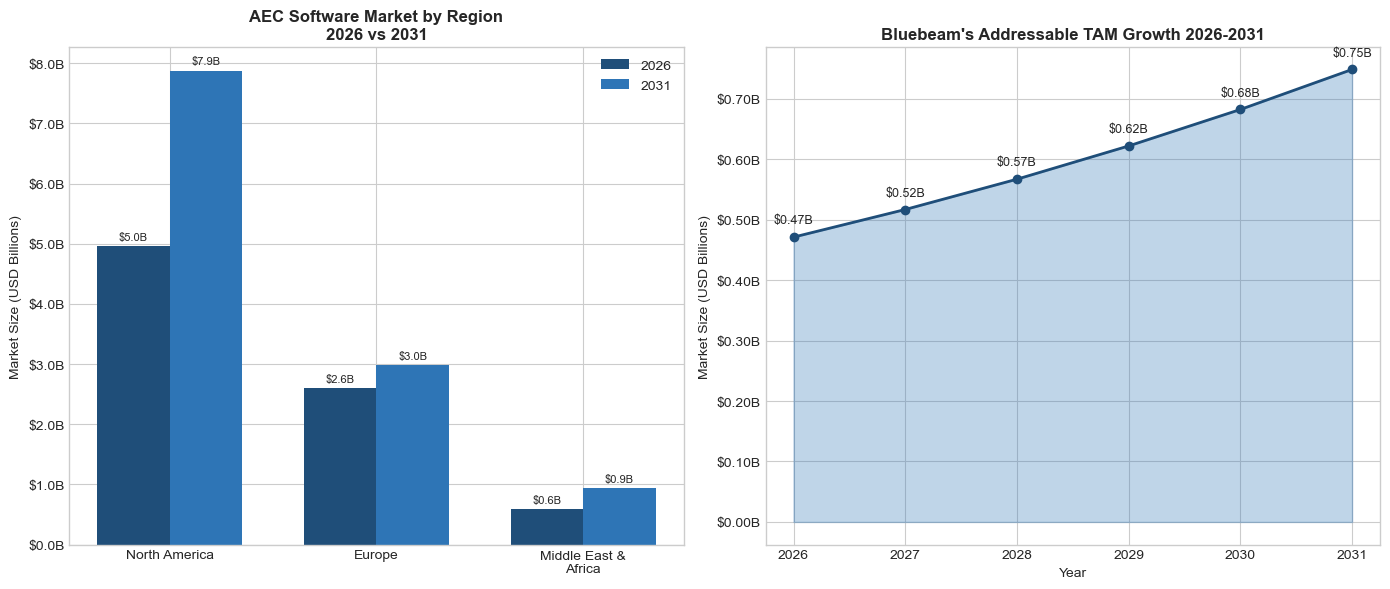

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left chart — Regional market comparison 2026 vs 2031
regions = ['North America', 'Europe', 'Middle East &\nAfrica']
values_2026 = [4.96, 2.60, 0.59]
values_2031 = [7.88, 2.98, 0.94]

x = np.arange(len(regions))
width = 0.35

axes[0].bar(x - width/2, values_2026, width, label='2026', color='#1f4e79')
axes[0].bar(x + width/2, values_2031, width, label='2031', color='#2e75b6')
axes[0].set_title('AEC Software Market by Region\n2026 vs 2031', fontweight='bold')
axes[0].set_ylabel('Market Size (USD Billions)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(regions)
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fB'))

# Add value labels on top of each bar
for rect in axes[0].patches:
    height = rect.get_height()
    axes[0].annotate(f'${height:.1f}B',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)

# Right chart — Bluebeam TAM growth over forecast period
axes[1].fill_between(years, bluebeam_tam, alpha=0.3, color='#2e75b6')
axes[1].plot(years, bluebeam_tam, marker='o', color='#1f4e79', linewidth=2)
axes[1].set_title("Bluebeam's Addressable TAM Growth 2026-2031", fontweight='bold')
axes[1].set_ylabel('Market Size (USD Billions)')
axes[1].set_xlabel('Year')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.2fB'))

for i, (year, val) in enumerate(zip(years, bluebeam_tam)):
    axes[1].annotate(f'${val:.2f}B', (year, val), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('market_sizing.png', dpi=150, bbox_inches='tight')
plt.show()

#### Section 2: Competitive Landscape

This section analyzes Bluebeam's four primary competitors across the AEC document collaboration space using aggregate review data from G2 (March 2026).

The analysis examines overall ratings, review volume as a proxy for market presence, and recurring themes from user feedback to identify competitive strengths, weaknesses, and differentiation opportunities.

Competitors analyzed:
- **Bluebeam Revu** — AEC-specific document markup and collaboration.
- **Adobe Acrobat** — General purpose PDF editing and management.
- **Procore** — Construction project management platform.
- **Autodesk Forma** (formerly Autodesk Construction Cloud) — BIM and construction collaboration.

In [13]:
# Competitive Landscape Data 
# Source: G2 aggregate review data, March 2026

competitors = {
    'Product': [
        'Bluebeam Revu',
        'Adobe Acrobat',
        'Procore',
        'Autodesk Construction Cloud'
    ],
    'G2 Rating': [4.6, 4.5, 4.6, 4.4],
    'Total Reviews': [450, 4444, 4102, 5273],
    'Top Positive Themes': [
        'Ease of Use, Tools, Intuitive, Document Management',
        'Ease of Use, Easy Editing, PDF Editing, Features',
        'Ease of Use, Project Management, Centralization, Document Management',
        'Ease of Use, Collaboration, Team Collaboration, Sharing'
    ],
    'Top Negative Themes': [
        'Learning Curve, Lack of Features, Expensive',
        'Expensive, Slow Performance, Not User-Friendly',
        'Missing Features, Learning Curve, Limitations',
        'Missing Features, Limitations, Lack of Features'
    ],
    'Primary Focus': [
        'AEC document markup & collaboration',
        'General PDF editing',
        'Construction project management',
        'BIM & construction collaboration'
    ]
}

comp_df = pd.DataFrame(competitors)
comp_df

,Product,G2 Rating,Total Reviews,Top Positive Themes,Top Negative Themes,Primary Focus
0,Bluebeam Revu,4.6,450,"Ease of Use, Tools, Intuitive, Document Manage...","Learning Curve, Lack of Features, Expensive",AEC document markup & collaboration
1,Adobe Acrobat,4.5,4444,"Ease of Use, Easy Editing, PDF Editing, Features","Expensive, Slow Performance, Not User-Friendly",General PDF editing
2,Procore,4.6,4102,"Ease of Use, Project Management, Centralizatio...","Missing Features, Learning Curve, Limitations",Construction project management
3,Autodesk Construction Cloud,4.4,5273,"Ease of Use, Collaboration, Team Collaboration...","Missing Features, Limitations, Lack of Features",BIM & construction collaboration


#### Key Findings: Competitive Landscape

All four products share strong ease of use ratings, suggesting that usability is now table stakes in this market rather than a differentiator. Bluebeam holds the highest rating alongside Procore at 4.6 but has significantly fewer reviews than competitors, indicating a smaller but highly specialized user base concentrated in the AEC sector.

Autodesk Construction Cloud leads in market presence with 5,273 reviews, followed by Adobe Acrobat at 4,444 and Procore at 4,102. Bluebeam's 450 reviews reflect its focused positioning within the AEC niche rather than broad horizontal adoption.

Pricing emerges as a recurring pain point for both Bluebeam and Adobe Acrobat, representing a potential vulnerability as competitors develop more cost-effective alternatives. Missing features and limitations are the dominant complaints for Procore and Autodesk, signaling opportunities for Bluebeam to differentiate through deeper AEC-specific functionality.

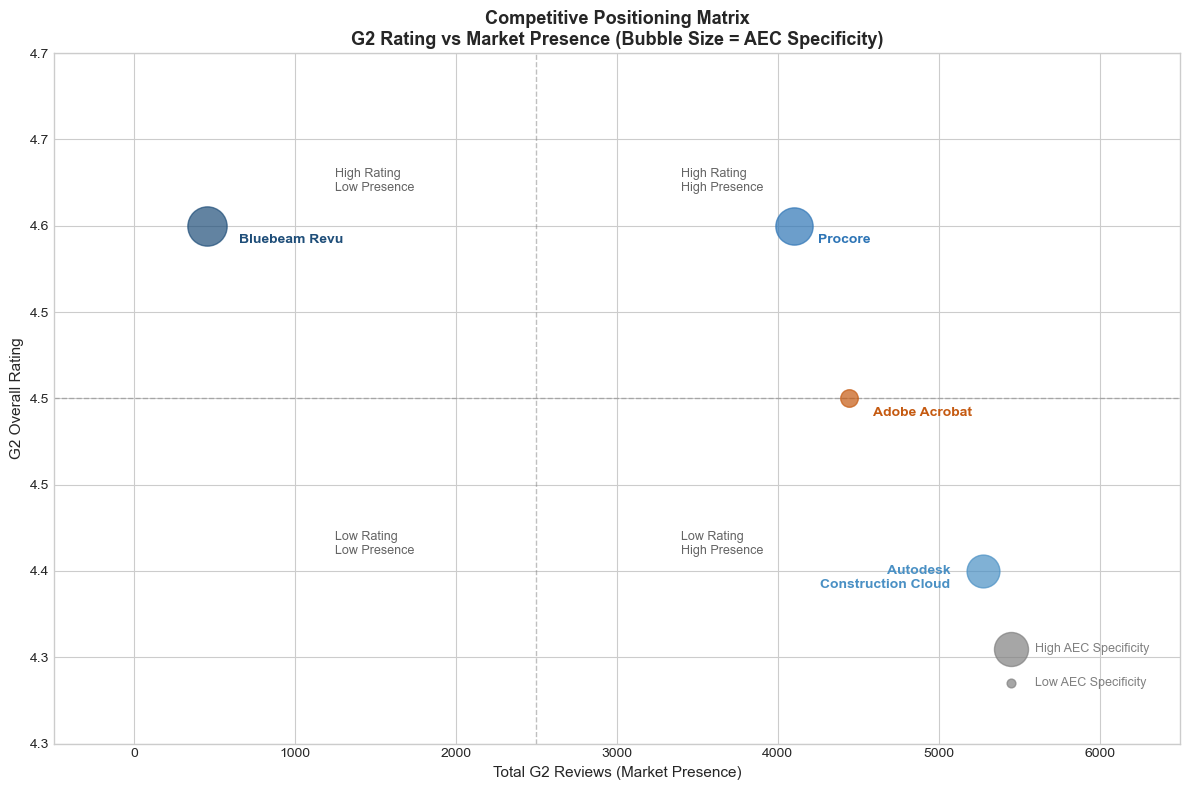

In [68]:
fig, ax = plt.subplots(figsize=(12, 8))

# Data
products = ['Bluebeam Revu', 'Adobe Acrobat', 'Procore', 'Autodesk\nConstruction Cloud']
ratings = [4.6, 4.5, 4.6, 4.4]
reviews = [450, 4444, 4102, 5273]

# Bubble size represents AEC specificity
# Higher = more AEC focused (subjective but defensible scoring)
# Bluebeam: 100 (pure AEC), Procore: 90 (AEC focused), 
# Autodesk: 70 (AEC + broader), Adobe: 20 (general purpose)
aec_specificity = [100, 20, 90, 70]
bubble_sizes = [s * 8 for s in aec_specificity]

colors = ['#1f4e79', '#c55a11', '#2e75b6', '#4a90c4']

for i, (product, rating, review, size, color) in enumerate(
    zip(products, ratings, reviews, bubble_sizes, colors)):
    
    ax.scatter(review, rating, s=size, color=color, alpha=0.7, zorder=3)
    
    # Position labels to avoid overlap
    offset_x = [200, 150, 150, -200]
    offset_y = [-0.01, -0.01, -0.01, -0.01]
    
    ax.annotate(product,
                xy=(review, rating),
                xytext=(review + offset_x[i], rating + offset_y[i]),
                fontsize=10, fontweight='bold', color=color,
                ha='left' if offset_x[i] > 0 else 'right')

# Reference lines
ax.axhline(y=4.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=2500, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Quadrant labels
ax.text(1250, 4.62, 'High Rating\nLow Presence', fontsize=9, color='#222222', alpha=0.7)
ax.text(3400, 4.62, 'High Rating\nHigh Presence', fontsize=9, color='#222222', alpha=0.7)
ax.text(1250, 4.41, 'Low Rating\nLow Presence', fontsize=9, color='#222222', alpha=0.7)
ax.text(3400, 4.41, 'Low Rating\nHigh Presence', fontsize=9, color='#222222', alpha=0.7)

ax.set_title('Competitive Positioning Matrix\nG2 Rating vs Market Presence (Bubble Size = AEC Specificity)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Total G2 Reviews (Market Presence)', fontsize=11)
ax.set_ylabel('G2 Overall Rating', fontsize=11)
ax.set_ylim(4.3, 4.7)
ax.set_xlim(-500, 6500)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# Legend for bubble size
ax.annotate('High AEC Specificity', xy=(5600, 4.355), fontsize=9, color='gray', va='center')
ax.annotate('Low AEC Specificity', xy=(5600, 4.335), fontsize=9, color='gray', va='center')

ax.scatter([5450], [4.355], s=600, color='gray', alpha=0.7)
ax.scatter([5450], [4.335], s=40, color='gray', alpha=0.7)

plt.tight_layout()
plt.savefig('competitive_positioning.png', dpi=150, bbox_inches='tight')
plt.show()

#### Section 3: EMEA Market Opportunity

Bluebeam currently maintains office presence across six countries: the United States, Australia, Germany, the United Kingdom, Sweden, and Denmark. This section evaluates the broader EMEA opportunity by analyzing market growth rates, BIM mandate adoption, and existing Bluebeam footprint across key European and Middle Eastern markets to identify where expansion efforts should be prioritized beyond the current office footprint.

BIM mandates are used as a proxy for market readiness, countries with active government-mandated BIM requirements on public projects signal higher digital maturity and stronger demand for construction collaboration software.

In [46]:
# EMEA Market Opportunity Analysis
# Source: MarketsandMarkets Europe BIM Report 2025,
# Future Market Insights Construction Design Software 2025,
# Statista Construction and Design Software Europe 2024
# Bluebeam office locations: bluebeam.com/company/contact

emea_countries = {
    'Country': [
        'Germany', 'United Kingdom', 'France',
        'Netherlands', 'Sweden', 'Denmark',
        'Norway', 'Saudi Arabia', 'UAE'
    ],
    'CAGR (%)': [12.9, 8.6, 7.2, 7.8, 6.5, 6.8, 6.8, 11.5, 10.2],
    'BIM Mandate': [
        'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'In Progress', 'Yes'
    ],
    'Bluebeam Presence': [
        'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No'
    ],
    'Market Opportunity': [
        'High', 'High', 'Medium', 'Medium',
        'Medium', 'Medium', 'Medium', 'High', 'High'
    ]
}

emea_df = pd.DataFrame(emea_countries)
emea_df

,Country,CAGR (%),BIM Mandate,Bluebeam Presence,Market Opportunity
0,Germany,12.9,Yes,Yes,High
1,United Kingdom,8.6,Yes,Yes,High
2,France,7.2,Yes,No,Medium
3,Netherlands,7.8,Yes,No,Medium
4,Sweden,6.5,Yes,Yes,Medium
5,Denmark,6.8,Yes,Yes,Medium
6,Norway,6.8,Yes,No,Medium
7,Saudi Arabia,11.5,In Progress,No,High
8,UAE,10.2,Yes,No,High


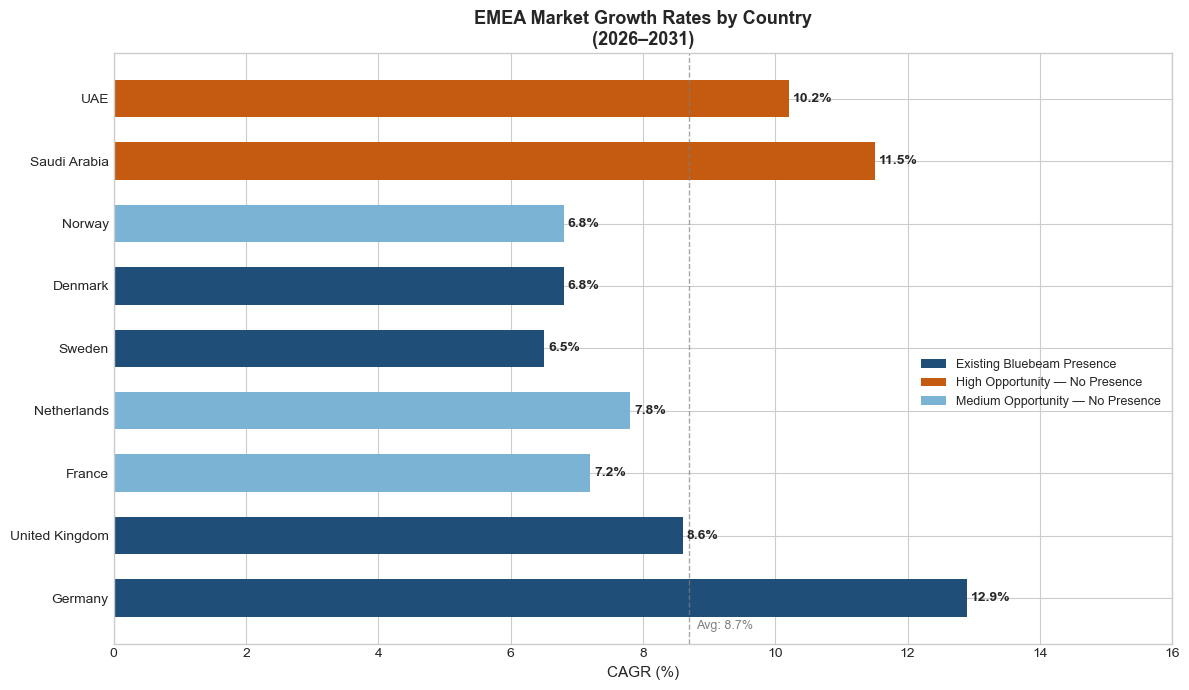

In [52]:
fig, ax = plt.subplots(figsize=(12, 7))

countries = emea_df['Country']
cagr = emea_df['CAGR (%)']
presence = emea_df['Bluebeam Presence']

# Color bars by presence and opportunity
bar_colors = []
for i, row in emea_df.iterrows():
    if row['Bluebeam Presence'] == 'Yes':
        bar_colors.append('#1f4e79')  # Dark blue — existing presence
    elif row['Market Opportunity'] == 'High':
        bar_colors.append('#c55a11')  # Orange — high opportunity, no presence
    else:
        bar_colors.append('#7ab3d4')  # Light blue — medium opportunity

bars = ax.barh(countries, cagr, color=bar_colors, height=0.6)

# Add value labels
for bar, val in zip(bars, cagr):
    ax.annotate(f'{val}%',
                xy=(val, bar.get_y() + bar.get_height() / 2),
                xytext=(3, 0), textcoords="offset points",
                va='center', fontsize=10, fontweight='bold')

# Add reference line at average CAGR
avg_cagr = emea_df['CAGR (%)'].mean()
ax.axvline(x=avg_cagr, color='gray', linestyle='--', alpha=0.7, linewidth=1)
ax.text(avg_cagr + 0.1, -0.5, f'Avg: {avg_cagr:.1f}%',
        fontsize=9, color='gray')

ax.set_title('EMEA Market Growth Rates by Country\n(2026–2031)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('CAGR (%)', fontsize=11)
ax.set_xlim(0, 16)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f4e79', label='Existing Bluebeam Presence'),
    Patch(facecolor='#c55a11', label='High Opportunity — No Presence'),
    Patch(facecolor='#7ab3d4', label='Medium Opportunity — No Presence')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, bbox_to_anchor=(1.0, 0.38))

plt.tight_layout()
plt.savefig('emea_opportunity.png', dpi=150, bbox_inches='tight')
plt.show()

#### Key Findings: EMEA Market Opportunity

Germany represents the strongest growth opportunity within Bluebeam's existing footprint at 12.9% CAGR, supported by strong government investment in transportation and public infrastructure and an active BIM mandate. Despite having an office in Munich, Germany's high growth rate suggests significant room for deeper market penetration.

Saudi Arabia (11.5% CAGR) and the UAE (10.2% CAGR) represent the highest growth opportunities where Bluebeam has no current standalone presence. Nemetschek, Bluebeam's parent company, launched operations in Saudi Arabia in 2025, explicitly bringing Bluebeam to the market, and has signed three strategic partnerships in the Kingdom: an MoU with Nesma Infrastructure and Technology (June 2025), a partnership with buildingSMART Saudi Arabia (August 2025), and a collaboration with Prince Sultan University (February 2026). This signals strong organizational momentum toward Middle East expansion that Bluebeam is directly positioned to benefit from.

France (7.2% CAGR) is already an active expansion market, Bluebeam appointed a Country Manager in January 2025 and has established presence through Nemetschek's brands. The recommendation is to accelerate this momentum rather than treat it as a new market entry.

The Netherlands (7.8% CAGR) has indirect presence through authorized resellers covering Belgium and the Netherlands. With an active BIM mandate and proximity to Bluebeam's existing European offices, the strategic opportunity is converting reseller relationships to a direct presence to capture more of the market growth.

#### Section 4: Strategic Recommendations

Based on the market sizing, competitive landscape, and EMEA opportunity analysis conducted in the preceding sections, three strategic recommendations are proposed for Bluebeam's growth priorities over the 2026-2031 forecast period.

In [58]:
# Strategic Recommendations Prioritization Matrix 

recommendations = {
    'Market': [
        'Germany (Expand Presence)',
        'Saudi Arabia (New Market Entry)',
        'France (Accelerate Expansion)',
        'Netherlands (Reseller to Direct)'
    ],
    'Market Growth (CAGR %)': [12.9, 11.5, 7.2, 7.8],
    'Market Readiness': [9, 8, 8, 7],
    'Organizational Readiness': [9, 8, 8, 6],
    'Strategic Priority': ['High', 'High', 'High', 'Medium']
}

rec_df = pd.DataFrame(recommendations)

# Calculate composite score
rec_df['Composite Score'] = (
    rec_df['Market Growth (CAGR %)'] * 0.4 +
    rec_df['Market Readiness'] * 3 * 0.3 +
    rec_df['Organizational Readiness'] * 3 * 0.3
).round(2)

rec_df

,Market,Market Growth (CAGR %),Market Readiness,Organizational Readiness,Strategic Priority,Composite Score
0,Germany (Expand Presence),12.9,9,9,High,21.36
1,Saudi Arabia (New Market Entry),11.5,8,8,High,19.00
2,France (Accelerate Expansion),7.2,8,8,High,17.28
3,Netherlands (Reseller to Direct),7.8,7,6,Medium,14.82


Based on the market sizing, competitive landscape, and EMEA opportunity analysis, three priority recommendations are proposed for Bluebeam's growth strategy over the 2026-2031 forecast period.

The competitive positioning analysis reveals a critical strategic insight: Bluebeam matches Procore's 4.6 G2 rating but holds only 450 reviews compared to Procore's 4,102 and Autodesk's 5,273. This is not a product quality problem, this suggests it is a distribution and awareness problem. The strategic lever is geographic and channel expansion.

**Recommendation 1: Expand Presence in Germany**
Germany combines the fastest European CAGR (12.9%), an existing Bluebeam office in Munich, and an active BIM mandate. Neither Autodesk nor Procore has established dominant positioning in Germany's precision-driven AEC market, creating a window to capture share before competitors deepen their European foothold. Investment in localized sales, training, and BIM mandate-aligned partnership programs would position Bluebeam to capitalize on this growth.

**Recommendation 2: Accelerate Saudi Arabia Expansion**
Saudi Arabia offers 11.5% CAGR driven by Vision 2030's infrastructure 
investment program. None of the competitors analyzed have established 
AEC-specific presence in the Kingdom, creating a genuine first-mover 
opportunity. Nemetschek has already built organizational infrastructure through three partnerships since June 2025 — with NIT, buildingSMART Saudi Arabia, and Prince Sultan University — explicitly bringing Bluebeam into the market. The recommendation is to accelerate Bluebeam-specific go-to-market activity by leveraging these existing partnerships.

**Recommendation 3: Accelerate France and Convert Netherlands to Direct Presence**
Bluebeam appointed a Country Manager in France in January 2025 with an 
established Nemetschek customer base to build from. Adobe Acrobat, 
Bluebeam's closest functional competitor, is consistently criticized for being expensive, slow, and poorly suited to AEC workflows, creating a direct substitution opportunity among French AEC professionals. The Netherlands, currently served through resellers, is a logical next step for direct market entry given its 7.8% CAGR, active BIM mandate, and proximity to existing European offices.

#### Conclusion

The global AEC software market is projected to grow from USD 11.80B in 2026 to USD 18.75B by 2031, with Bluebeam's addressable TAM growing from USD 0.47B to USD 0.75B. Bluebeam's 4.6 G2 rating matches Procore and exceeds Autodesk, but its 450 reviews against competitors ranging from 4,102 to 5,273 confirms the core challenge is distribution, not product quality.

Three markets emerge as priorities: Germany, where existing infrastructure and the fastest European CAGR create a penetration opportunity before competitors establish dominance; Saudi Arabia, where Nemetschek's active expansion provides first-mover organizational momentum no competitor has matched; and France and 
the Netherlands, where Adobe Acrobat's documented weaknesses in AEC workflows create a direct substitution opportunity for Bluebeam's purpose-built solution.

Bluebeam's AEC-specific focus, strong user satisfaction, and parent company infrastructure position it well to capture a disproportionate share of market growth, provided expansion is prioritized around markets with the strongest combination of growth, readiness, and organizational momentum.